In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
Linear_model = LinearRegression()
Forest_model = RandomForestRegressor()
data = pd.read_csv('Critical_Sales_Data.csv')

In [2]:
data = data.drop('Invoice_ID' , axis=1)

In [3]:
pd.DataFrame(data['Customer_ID'].unique())

,0
0,1428
1,4162
2,3492
3,2256
4,3910
...,...
3783,4006
3784,1444
3785,2764
3786,2722


In [4]:
data

,Date,Customer_Name,Customer_ID,Region,Product,Category,Product_ID,Quantity,Unit_Price,Total_Amount
0,01-01-2023 00:00,Arjun Desai,1428,Central,Mobile Phone,Electronics,PID147,1,544.48,544.48
1,01-01-2023 01:00,Neha Rao,4162,West,Rice Cooker,Home Appliances,PID145,9,758.62,6827.58
2,01-01-2023 02:00,Arjun Desai,3492,Central,T-Shirt,Clothing,PID113,3,1392.82,4178.46
3,01-01-2023 03:00,Amit Shah,2256,West,T-Shirt,Clothing,PID127,7,1275.70,8929.90
4,01-01-2023 04:00,Sneha Kulkarni,3910,Central,Microwave,Home Appliances,PID134,6,2059.04,12354.24
...,...,...,...,...,...,...,...,...,...,...
11995,14-05-2024 19:00,Karan Patel,2689,East,LED TV,Electronics,PID131,6,864.00,5184.00
11996,14-05-2024 20:00,Sneha Kulkarni,2864,East,Jeans,Clothing,PID107,7,1892.27,13245.89
11997,14-05-2024 21:00,Amit Shah,2320,East,Mobile Phone,Electronics,PID147,5,1623.56,8117.80
11998,14-05-2024 22:00,Amit Shah,2738,West,Rice Cooker,Home Appliances,PID120,1,166.44,166.44


In [5]:
LR_data = data[['Quantity' ,'Unit_Price','Total_Amount' ]]
LR_data

,Quantity,Unit_Price,Total_Amount
0,1,544.48,544.48
1,9,758.62,6827.58
2,3,1392.82,4178.46
3,7,1275.70,8929.90
4,6,2059.04,12354.24
...,...,...,...
11995,6,864.00,5184.00
11996,7,1892.27,13245.89
11997,5,1623.56,8117.80
11998,1,166.44,166.44


In [6]:
x = LR_data[['Quantity' , 'Unit_Price']]
y = LR_data['Total_Amount']

In [7]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
y_test

1935      7286.40
6494     10026.10
1720      4820.30
9120     11248.56
360       4934.40
           ...   
1195      2090.40
11877     5854.26
5421     14582.64
3855     12160.89
4414      4649.04
Name: Total_Amount, Length: 2400, dtype: float64

## Linear Model Traning ##

In [8]:
Linear_model.fit(x_train , y_train)

LinearRegression()

In [9]:
y_test_reset_indx = y_test.reset_index(drop=True)
prediction_LR = Linear_model.predict(x_test)
prediction_LR_df = pd.DataFrame({'Prediction_LR' : prediction_LR})
prediction_LR_df['Actual'] = y_test_reset_indx
prediction_LR_df

,Prediction_LR,Actual
0,7810.674316,7286.40
1,10048.751501,10026.10
2,4806.452970,4820.30
3,10972.618718,11248.56
4,5406.727256,4934.40
...,...,...
2395,1270.137039,2090.40
2396,6178.651636,5854.26
2397,13071.028506,14582.64
2398,11326.688878,12160.89


<Axes: xlabel='Actual', ylabel='Prediction_LR'>

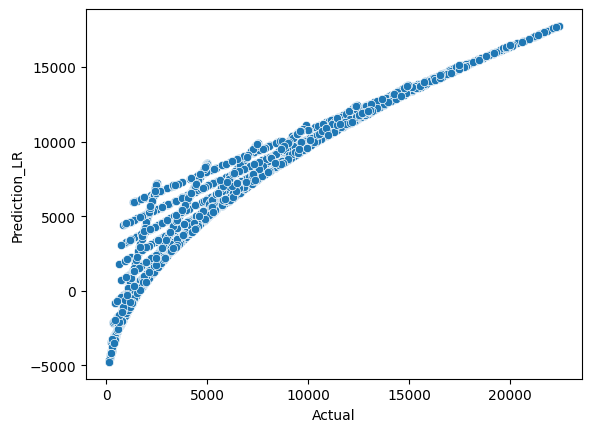

In [10]:
sns.scatterplot(data= prediction_LR_df , x=prediction_LR_df['Actual'] , y = prediction_LR_df['Prediction_LR'])
# something is wrong with the traning data since it's predicting in minus 

## Random_Forest Traning ##

In [11]:
Forest_model.fit(x_train , y_train)

RandomForestRegressor()

In [12]:
prediction_RF = Forest_model.predict(x_test)
prediction_RF_df = pd.DataFrame({'Prediction_RF' : prediction_RF})
prediction_RF_df['Actual'] = y_test_reset_indx
prediction_RF_df

,Prediction_RF,Actual
0,7284.5728,7286.40
1,10022.5980,10026.10
2,4831.0605,4820.30
3,11252.0208,11248.56
4,4934.6826,4934.40
...,...,...
2395,2089.9940,2090.40
2396,5850.7644,5854.26
2397,14570.6872,14582.64
2398,12163.3330,12160.89


<Axes: xlabel='Actual', ylabel='Prediction_RF'>

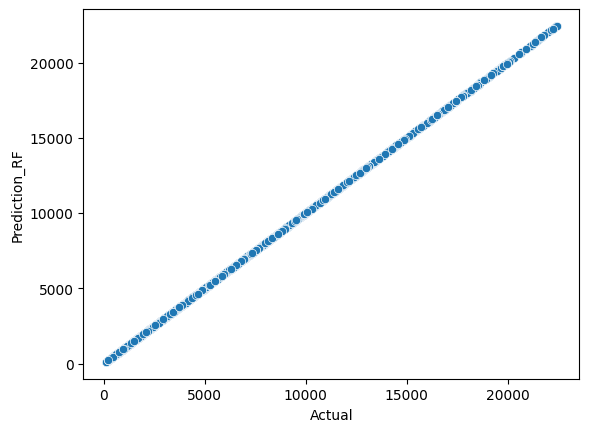

In [13]:
sns.scatterplot(data= prediction_RF_df , x=prediction_RF_df['Actual'] , y = prediction_RF_df['Prediction_RF'])
# Random Forest's prediction are more accurate 